In [10]:
import os
import re
import time
import glob
import math
import random
import joblib
import numpy as np
from PIL import Image

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe

import scipy
import skimage
import sklearn
from sklearn.metrics import accuracy_score

np.random.seed(0)
random.seed(0)

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h

def convert_name(name: str) -> str:
    name = name.strip()

    m = re.match(r'^(Var|Mean)\_?(.*)$', name)

    if m:
        prefix, rest = m.group(1), m.group(2)
        prefix = prefix.capitalize()
    else:
        return name.split()[0]

    rest = re.sub(r'\$T_\{(\d+)\}\$', r'T\1', rest)

    if '|' in rest and '/' in rest and re.search(r'T_\{\d+\}', rest):
        nums = re.findall(r'T_\{(\d+)\}', rest)
        if len(nums) >= 2:
            nums = sorted(set(nums), key=int)
            return f"ND_{nums[0]}_{nums[-1]}"

    rest = re.sub(r'[\$\{\}\|\(\)]', '', rest)
    rest = re.sub(r'T_(\d+)', r'T\1', rest)

    return f"{prefix}_{rest}" if rest else prefix

def load_plt_setting():
    mpl.style.use('seaborn-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    mpl.rcParams["font.weight"] = "normal"
    mpl.rcParams["axes.labelweight"] = "normal"
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

# 1. Preprocessing

In [14]:
#########################
# Specify the dataset name here.
# The dataset should be located under "LeafSpec-FeatureMap/dataset/".
# It should follow a directory structure of name/hsi/L0.
dataset_name = 'X1D'
#########################

root_path = os.getcwd()
folder = os.path.join(root_path,'dataset', dataset_name)
full_files = glob.glob(os.path.join(folder,'hsi','L0','*','*.npy'))

processed_path = os.path.join(root_path,'processed',dataset_name)
os.makedirs(processed_path, exist_ok=True)

wav = np.linspace(530, 530+531*0.75, 532)
files = []
for file in full_files:
    if not any(keyword in file for keyword in ['heatmap','imgPst','specLeaf','specsLeaf','whRef',]):
        files.append(file)

for k, file in enumerate(files[:]):
    file = file.split('\\')[-1][:-4]
    try:
        data = np.load(os.path.join(folder,'hsi','L0','{}'.format(file),'{}.npy'.format(file)))
    except:
        print(k, file,'Loading failed, skip.')
        continue
        
    try:
        white = np.load(os.path.join(folder,'hsi','L0','{}'.format(file),'{}_whRef.npy'.format(file)))
    except:
        print(k, file, 'Load white ref failed.')
        pass
    
    cal = np.array(data,dtype=float)
    x_shifts = np.linspace(0,-3,cal.shape[-1])
    for i in range(len(x_shifts)):
        cal[:,:,i] = scipy.ndimage.shift(cal[:,:,i],(x_shifts[i],0))
    cal = cal[:-3,25:,:]

    white_cal = np.array(white,dtype=float)
    x_shifts = np.linspace(0,-3,white_cal.shape[-1])
    for i in range(len(x_shifts)):
        white_cal[:,:,i] = scipy.ndimage.shift(white_cal[:,:,i],(x_shifts[i],0))
    white_cal = white_cal[:-3,25:,:]

    cal = cal/white_cal[:,:cal.shape[1],:]
    for i in range(cal.shape[0]):
        for j in range(cal.shape[1]):
            if np.mean(cal[i,j,190:210]) > 0.4:
                cal[i,j,:] = np.nan
            else:
                cal[i,j,:] = cal[i,j,:]/np.mean(cal[i,j,-31:-1])

    nans = np.isnan(cal[:,:,0])
    nancols = np.all(nans, axis=0)
    nanrows = np.all(nans, axis=1)
    firstcol = nancols.argmin()
    firstrow = nanrows.argmin()
    lastcol = len(nancols)-nancols[::-1].argmin()
    lastrow = len(nanrows)-nanrows[::-1].argmin()
    cal = cal[firstrow:lastrow,firstcol:lastcol,:]/1.15
    cal = cal.astype('float32')

    np.save(os.path.join(processed_path,'{}.npy'.format(file)), cal)
    
    out = ~np.isnan(cal[:,:,0])
    out[out==False] = 0
    out[out==True] = 1
    im = Image.fromarray(np.uint8(out*255))
    im.save(os.path.join(processed_path,'{}_mask.png'.format(file)))
    print(k, file, cal.shape)

0 X1D-ZM-CDO-DR-T06-07D-S1-P1-LTS_2026-04-27T14_51_47.757319+00_00 (83, 129, 532)
1 X1D-ZM-CDO-DR-T06-07D-S1-P2-LTS_2026-04-27T14_52_47.884047+00_00 (65, 136, 532)
2 X1D-ZM-CDO-DR-T06-07D-S1-P3-LTS_2026-04-27T14_53_52.373259+00_00 (74, 128, 532)
3 X1D-ZM-CDO-DR-T06-07D-S2-P1-LTS_2026-04-27T15_48_55.924848+00_00 (61, 119, 532)
4 X1D-ZM-CDO-DR-T06-07D-S2-P2-LTS_2026-04-27T15_49_52.103629+00_00 (87, 121, 532)
5 X1D-ZM-CDO-DR-T06-07D-S2-P3-LTS_2026-04-27T15_50_56.302900+00_00 (62, 127, 532)
6 X1D-ZM-CDO-DR-T06-07D-S3-P1-LTS_2026-04-27T16_14_11.869970+00_00 (81, 118, 532)
7 X1D-ZM-CDO-DR-T06-07D-S3-P2-LTS_2026-04-27T16_16_23.352313+00_00 (53, 121, 532)
8 X1D-ZM-CDO-DR-T06-07D-S3-P3-LTS_2026-04-27T16_17_01.969593+00_00 (82, 127, 532)
9 X1D-ZM-CDO-DR-T06-07D-S3-P4-LTS_2026-04-27T16_17_40.822480+00_00 (63, 129, 532)
10 X1D-ZM-CDO-DR-T07-07D-S1-P1-LTS_2026-04-27T14_56_16.524422+00_00 (73, 135, 532)
11 X1D-ZM-CDO-DR-T07-07D-S1-P2-LTS_2026-04-27T15_25_57.067595+00_00 (71, 130, 532)
12 X1D-ZM-CDO-

# 2. Loading the data

In [2]:
class Soybean_DataLoader():
    '''
    [Input]
    folder:              Folder to .npy cubes (H,W,C)
    dic_path:            Path to data dictionary, will be generated after first run for loading speed-up
    day:                 The date after treatment (choose either '24H' or '07D')
    [Output]
    Xs:                  Array of X in (n,C1,C2,H,W), n=batch_size
    '''
    def __init__(self, folder, dic_path, day):
        
        self.data = {}
        for heading in ['X','Mask','Index','Name','PlantID','LeafID','Treatment','Y']:
            self.data[heading] = []
        
        # Load X file paths
        self.files = glob.glob(folder+'\*.npy')
        
        if os.path.isfile(dic_path):
            with open(dic_path, 'rb') as handle:
                self.data = joblib.load(handle)
            print('Data loaded.')
            
        else:
            print('Data dic not found, processing raw data')

            for i, file in enumerate(self.files):
                file_name = file.split('\\')[-1][:-4]
                namesplit = file_name.split('-')
                if namesplit[5] != day:
                    continue
                treatment, leafID, plantID = '{}-{}-{}'.format(namesplit[2],namesplit[3],namesplit[4]), namesplit[6], namesplit[7]

                data = np.load(file)
                mask = np.asarray(Image.open(file[:-4]+'_mask.png'))[:,:]
                
                self.data['X'].append(data)
                self.data['Mask'].append(mask)
                self.data['Index'].append(i)
                self.data['Name'].append(file_name)
                self.data['PlantID'].append(plantID)
                self.data['LeafID'].append(leafID)
                self.data['Treatment'].append(treatment)
                print('{}/{}\t{}\t{}\t{}\t{}'.format(i+1,len(self.files),data.shape,treatment,plantID,leafID))
                
            with open(dic_path, 'wb') as handle:
                joblib.dump(self.data, handle)
            print('Data generated.')

In [3]:
dataset_name = 'X1D'
root_path = os.getcwd()
processed_path = os.path.join(root_path,'processed',dataset_name)

#########################
# Select either '24H' or '07D' for analysis. (24 hours after treatment / 7 days after treatment)
day = '07D'  
#########################

soybean_dataloader = Soybean_DataLoader(folder=processed_path, 
                                        dic_path=os.path.join(processed_path,'{}.pkl'.format(day)), day=day)

Data loaded.


# 3. Feature map visualization

In [6]:
#########################
# List the treatment groups of interest below.
treatment_include = ['MCK-NT-T01','CDO-DR-T07']
#########################

wav = np.linspace(530, 530+531*0.75, 532)
c_channels = np.arange(550, 801, 25)
wav_idx = np.searchsorted(wav, c_channels)
wav_idx = np.clip(wav_idx, 1, len(wav)-1)
wav_idx = wav_idx - (np.abs(c_channels - wav[wav_idx-1]) < np.abs(c_channels - wav[wav_idx]))

i = 0
print('{}\t{}'.format('Index', 'Treatment'))
for j,treatment in enumerate(soybean_dataloader.data['Treatment']):
    if treatment in treatment_include:
        print('{}\t{}'.format(j, treatment))
        i+=1

Index	Treatment
10	CDO-DR-T07
11	CDO-DR-T07
12	CDO-DR-T07
13	CDO-DR-T07
14	CDO-DR-T07
15	CDO-DR-T07
16	CDO-DR-T07
17	CDO-DR-T07
18	CDO-DR-T07
19	CDO-DR-T07
20	MCK-NT-T01
21	MCK-NT-T01
22	MCK-NT-T01
23	MCK-NT-T01
24	MCK-NT-T01
25	MCK-NT-T01
26	MCK-NT-T01
27	MCK-NT-T01
28	MCK-NT-T01
29	MCK-NT-T01


In [11]:
#########################
# In some cases, the treatment group may have non-contiguous indices.
# Please manually specify the indices of the desired samples below.
# Up to 9 leaves (3 × 3) can be plotted for visualization.
group_name = ['T01 - Mock control (water drench)','T07 - Cadmium oxide (50 g/L)']
group_1 = [20,21,22,23,24,25,26,27,28]
group_2 = [10,11,12,13,14,15,16,17,18]
#########################

group_list = [group_1, group_2]
os.makedirs(os.path.join(root_path,'results',dataset_name), exist_ok=True)

## 3.1 Single band transmittance T

In [12]:
#########################
# Figures will be stored under "LeafSpec-FeatureMap/results/".
#########################

load_plt_setting()

for channel in wav_idx:
    all_Xs = []
    for sample_list in group_list:
        for idx in sample_list:
            X = np.mean(soybean_dataloader.data['X'][idx][:,:,channel-4:channel+4],axis=-1)
            X[X == 0] = np.nan
            all_Xs.append(skimage.transform.resize(X,(80,140)))

    all_Xs = np.array(all_Xs)
    global_min, global_max = np.nanpercentile(all_Xs, 0.1), np.nanpercentile(all_Xs, 99.9)

    for k, (sample_name, sample_list) in enumerate(zip(group_name, group_list)):
        fig, ax = plt.subplots(figsize=(15, 8))
        ax.axis('off')

        gs = fig.add_gridspec(3, 3, hspace=0, wspace=0)
        axes = gs.subplots(sharex='col', sharey='row')

        for i in range(3):
            for j in range(3):
                mat = axes[i,j].matshow(all_Xs[k*9+i*3+j], cmap='Spectral_r', vmin=global_min, vmax=global_max)
                axes[i,j].axis('off')

        cbar = plt.colorbar(mat, ax=axes, shrink=0.9, fraction=0.05, pad=0.03)
        cbar.ax.tick_params(axis='y', direction='out', length=8, width=2, pad=5, labelsize=28)
        cbar.ax.tick_params(axis='y', which='minor', direction='out', length=4, width=2, pad=5, labelsize=28)
        cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
        cbar.ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
        cbar.ax.set_ylabel(r'$T_{{{}}}$'.format(int(np.round(wav[channel]))), labelpad=45, rotation=-90, fontsize=34)

        ax.text(0.5, 1.05, sample_name, fontsize=34, ha='center', va='bottom', transform=ax.transAxes, zorder=100)
        save_name = '{}_{}'.format(int(np.round(wav[channel])),sample_name.split(' ')[0])
        plt.savefig(os.path.join(root_path,'results',dataset_name,'{}.png'.format(save_name)), 
                    format='png', dpi=300, transparent=True, bbox_inches='tight')
        
        print(save_name, ' done!')
        plt.clf()
        plt.close()
#     break

C:\Users\axvcb\AppData\Local\Temp\ipykernel_79800\4147104598.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


550_T01  done!
550_T07  done!
575_T01  done!
575_T07  done!
600_T01  done!
600_T07  done!
625_T01  done!
625_T07  done!
650_T01  done!
650_T07  done!
675_T01  done!
675_T07  done!
700_T01  done!
700_T07  done!
725_T01  done!
725_T07  done!
750_T01  done!
750_T07  done!
775_T01  done!
775_T07  done!
800_T01  done!
800_T07  done!


## 3.2 Normalized difference (T1-T2)/(T1+T2)

In [14]:
#########################
# Figures will be stored under "LeafSpec-FeatureMap/results/".
#########################

load_plt_setting()

for c1 in wav_idx:
    for c2 in wav_idx:
        wav1 = int(np.round(wav[c1]))
        wav2 = int(np.round(wav[c2]))
        
        if c1 < c2:
            all_Xs = []
            for sample_list in group_list:
                for idx in sample_list:
                    X1 = np.mean(soybean_dataloader.data['X'][idx][:,:,c1-4:c1+4],axis=-1)
                    X2 = np.mean(soybean_dataloader.data['X'][idx][:,:,c2-4:c2+4],axis=-1)
                    X1[X1 == 0] = np.nan
                    X = abs((X1-X2)/(X1+X2))
                    all_Xs.append(skimage.transform.resize(X,(80,140)))

            all_Xs = np.array(all_Xs)
            global_min, global_max = np.nanpercentile(all_Xs, 0.1), np.nanpercentile(all_Xs, 99.9)

            for k, (sample_name, sample_list) in enumerate(zip(group_name, group_list)):
                fig, ax = plt.subplots(figsize=(15, 8))
                ax.axis('off')

                gs = fig.add_gridspec(3, 3, hspace=0, wspace=0)
                axes = gs.subplots(sharex='col', sharey='row')

                for i in range(3):
                    for j in range(3):
                        mat = axes[i,j].matshow(all_Xs[k*9+i*3+j], cmap='Spectral_r', vmin=global_min, vmax=global_max)
                        axes[i,j].axis('off')

                cbar = plt.colorbar(mat, ax=axes, shrink=0.9, fraction=0.05, pad=0.03)
                cbar.ax.tick_params(axis='y', direction='out', length=8, width=2, pad=5, labelsize=28)
                cbar.ax.tick_params(axis='y', which='minor', direction='out', length=4, width=2, pad=5, labelsize=28)
                cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
                cbar.ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
                cbar.ax.set_ylabel(r'$|(T_{{{}}}-T_{{{}}})/(T_{{{}}}+T_{{{}}})|$'.format(wav1,wav2,wav1,wav2), labelpad=45, rotation=-90, fontsize=34)

                ax.text(0.5, 1.05, sample_name, fontsize=34, ha='center', va='bottom', transform=ax.transAxes, zorder=100)
                save_name = 'ND_{}_{}_{}'.format(wav1,wav2,sample_name.split(' ')[0])
                plt.savefig(os.path.join(root_path,'results',dataset_name,'{}.png'.format(save_name)), 
                            format='png', dpi=300, transparent=True, bbox_inches='tight')

                print(save_name, ' done!')
                plt.clf()
                plt.close()

C:\Users\axvcb\AppData\Local\Temp\ipykernel_79800\4147104598.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


ND_550_575_T01  done!
ND_550_575_T07  done!
ND_550_600_T01  done!
ND_550_600_T07  done!
ND_550_625_T01  done!
ND_550_625_T07  done!
ND_550_650_T01  done!
ND_550_650_T07  done!
ND_550_675_T01  done!
ND_550_675_T07  done!
ND_550_700_T01  done!
ND_550_700_T07  done!
ND_550_725_T01  done!
ND_550_725_T07  done!
ND_550_750_T01  done!
ND_550_750_T07  done!
ND_550_775_T01  done!
ND_550_775_T07  done!
ND_550_800_T01  done!
ND_550_800_T07  done!
ND_575_600_T01  done!
ND_575_600_T07  done!
ND_575_625_T01  done!
ND_575_625_T07  done!
ND_575_650_T01  done!
ND_575_650_T07  done!
ND_575_675_T01  done!
ND_575_675_T07  done!
ND_575_700_T01  done!
ND_575_700_T07  done!
ND_575_725_T01  done!
ND_575_725_T07  done!
ND_575_750_T01  done!
ND_575_750_T07  done!
ND_575_775_T01  done!
ND_575_775_T07  done!
ND_575_800_T01  done!
ND_575_800_T07  done!
ND_600_625_T01  done!
ND_600_625_T07  done!
ND_600_650_T01  done!
ND_600_650_T07  done!
ND_600_675_T01  done!
ND_600_675_T07  done!
ND_600_700_T01  done!
ND_600_700

# 4. Feature significance test

In [7]:
#########################
# Compute the mean and variance of various feature maps for each sample.
#########################

wav = np.linspace(530, 530+531*0.75, 532)
c_channels = np.arange(550, 801, 25)
wav_idx = np.searchsorted(wav, c_channels)
wav_idx = np.clip(wav_idx, 1, len(wav)-1)
wav_idx = wav_idx - (np.abs(c_channels - wav[wav_idx-1]) < np.abs(c_channels - wav[wav_idx]))

indexes = {'Mean_NDVI':[],'Var_NDVI':[],'Mean_ARI':[],'Var_ARI':[],'Size (cm$^2$)':[]}

for (wav1,i) in zip(c_channels,wav_idx):
        indexes[r'Mean_$T_{{{}}}$'.format(wav1)] = []
        indexes[r'Var_$T_{{{}}}$'.format(wav1)] = []
        for (wav2,j) in zip(c_channels,wav_idx):
            if i > j:
                indexes[r'Mean_$|(T_{{{}}}-T_{{{}}})/(T_{{{}}}+T_{{{}}})|$'.format(wav1,wav2,wav1,wav2)] = []
                indexes[r'Var_$|(T_{{{}}}-T_{{{}}})/(T_{{{}}}+T_{{{}}})|$'.format(wav1,wav2,wav1,wav2)] = []
                
for idx, X in enumerate(soybean_dataloader.data['X']):
    mask = np.array(soybean_dataloader.data['Mask'][idx])
    mask_Xs = np.zeros((X.shape))
    for i in range(mask_Xs.shape[0]):
        for j in range(mask_Xs.shape[1]):
            if mask[i,j] == 0:
                mask_Xs[i,j,:] = np.nan
            else:
                mask_Xs[i,j,:] = X[i,j,:]
    
    nans = np.isnan(mask_Xs[:,:,0])
    nancols = np.all(nans, axis=0)
    nanrows = np.all(nans, axis=1)
    firstcol = nancols.argmin()
    firstrow = nanrows.argmin()
    lastcol = len(nancols)-nancols[::-1].argmin()
    lastrow = len(nanrows)-nanrows[::-1].argmin()
    mask_Xs = mask_Xs[firstrow:lastrow,firstcol:lastcol,:]
    
    # NDVI
    index630 = abs(wav-630).argmin()
    index800 = abs(wav-800).argmin()
    
    NDVI = (mask_Xs[:,:,index800]-mask_Xs[:,:,index630])/(mask_Xs[:,:,index800]+mask_Xs[:,:,index630])
    indexes['Mean_NDVI'].append(np.nanmean(NDVI))
    indexes['Var_NDVI'].append(np.nanvar(NDVI))
    size = np.sum(~np.isnan(X[:,:,0]))*(10.7*9.6/721/782)*4
    indexes['Size (cm$^2$)'].append(size)

    index550 = abs(wav-550).argmin()
    index700 = abs(wav-700).argmin()
    ARI = 1/mask_Xs[:,:,index550]-1/mask_Xs[:,:,index700]
    indexes['Mean_ARI'].append(np.nanmean(ARI))
    indexes['Var_ARI'].append(np.nanvar(ARI))
    
    for (wav1,i) in zip(c_channels,wav_idx):
        X_mean = np.nanmean(mask_Xs[:,:,i-4:i+4])
        X_var = np.nanvar(mask_Xs[:,:,i-4:i+4])
        indexes[r'Mean_$T_{{{}}}$'.format(wav1)].append(X_mean)
        indexes[r'Var_$T_{{{}}}$'.format(wav1)].append(X_var)
        
        for (wav2,j) in zip(c_channels,wav_idx):
            if i > j:
                X1 = np.nanmean(mask_Xs[:,:,i-4:i+4],axis=-1)
                X2 = np.nanmean(mask_Xs[:,:,j-4:j+4],axis=-1)
                X_mean = np.nanmean(abs((X1-X2)/(X1+X2)))
                X_var = np.nanvar(abs((X1-X2)/(X1+X2)))
                indexes[r'Mean_$|(T_{{{}}}-T_{{{}}})/(T_{{{}}}+T_{{{}}})|$'.format(wav1,wav2,wav1,wav2)].append(X_mean)
                indexes[r'Var_$|(T_{{{}}}-T_{{{}}})/(T_{{{}}}+T_{{{}}})|$'.format(wav1,wav2,wav1,wav2)].append(X_var)
print('Feature generated!')

C:\Users\axvcb\AppData\Local\Temp\ipykernel_85468\892332406.py:64: RuntimeWarning: Mean of empty slice
  X1 = np.nanmean(mask_Xs[:,:,i-4:i+4],axis=-1)
C:\Users\axvcb\AppData\Local\Temp\ipykernel_85468\892332406.py:65: RuntimeWarning: Mean of empty slice
  X2 = np.nanmean(mask_Xs[:,:,j-4:j+4],axis=-1)


Feature generated!


In [40]:
#########################
# Select the treatment groups for significance testing.
# If more than two groups are selected, pairwise tests will be performed.
# Note: the sample size should be consistent across groups.
group_name = ['Control','CdO','CdO↑']
group_list = ['MCK-NT-T01','CDO-DR-T06','CDO-DR-T07']
group_c_list = {'MCK-NT-T01':colors.to_rgba("#139fcd"),
                'CDO-DR-T06':colors.to_rgba("#ffd166"),
                'CDO-DR-T07':colors.to_rgba("#f26989"),}
#########################

labels = np.array(soybean_dataloader.data['Treatment'])
idx = np.array(soybean_dataloader.data['Index'])
idx = np.arange(0,len(idx),1)

c_list = [colors.to_rgba("#139fcd"),colors.to_rgba("#ffd166"),colors.to_rgba("#f26989")]
load_plt_setting()

for k, method_name in enumerate(indexes.keys()):
    
    if 'Mean' in method_name:
        label_name = '$\mu$' + '({})'.format(method_name[5:])
    elif 'Var' in method_name:
        label_name = '$\sigma^2$' + '({})'.format(method_name[4:])
    
    fig, ax = plt.subplots(figsize=(5.5, 5))
    method_y = []
    for i, group in enumerate(group_list):
        j = idx[np.where(labels==group)[0]]
        y = np.array(indexes[method_name])[j]
        method_y.append(y)
        x_variation = 0.25
        x = np.random.uniform(i-x_variation, i+x_variation, size=y.shape[0])
        ax.scatter(x, y, c=[c_list[i]]*y.shape[0], alpha=1, s=200, edgecolor="black", linewidth=2, clip_on=True)

        y_mean, y_error = mean_confidence_interval(y)
        ax.bar(i, y_mean, color=[c_list[i][:-1]+(0.7,)], width=0.6, zorder=-1, linewidth=2, edgecolor="black")
        ax.errorbar(i, y_mean, yerr=[[0],[np.std(y)]], elinewidth=2, ecolor='black', capsize=5, capthick=2, zorder=-1)

    ax.tick_params(axis='both', direction='out', length=8, width=2, pad=10, labelsize=28)
    ax.tick_params(axis='both', which='minor', direction='out', length=4, width=2, pad=10)
    ax.tick_params(axis='x', direction='out', length=8, width=2, pad=10, labelsize=28)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 4, 5, 10]))
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.set_xlim([-0.7,len(group_list)-0.3])
    ax.set_ylim([0,np.max(np.array(method_y))*1.2])

    plt.xticks(np.linspace(0,len(group_list)-1,len(group_list)), group_name, size=28)
    ax.set_xlabel('Treatment', labelpad=25, fontsize=28)
    ax.set_ylabel(label_name, labelpad=25, fontsize=28)
#     ax.text(0.5, 1.05, method_name, fontsize=32, ha='center', va='bottom', transform=ax.transAxes)

    # ============================== Significance =========================================
    significant_combinations = []
    ls = list(range(0, len(group_list)))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for combination in combinations:
        U, p = scipy.stats.mannwhitneyu(method_y[combination[0]],method_y[combination[1]], alternative='two-sided')
        if p < 0.05:
            significant_combinations.append([combination, p])

    bottom, top = ax.get_ylim()
    y_range = top - bottom

    title_height = top*0.9
    for j, significant_combination in enumerate(significant_combinations):
        x1 = significant_combination[0][0]
        x2 = significant_combination[0][1]
        level = len(significant_combinations) - j
        bar_height = (y_range * 0.17* level) + top*0.8
        if j == 0:
            title_height = bar_height

        bar_tips = bar_height - (y_range * 0.02)
        ax.plot([x1, x1, x2, x2], [bar_tips, bar_height, bar_height, bar_tips], c='black', linewidth=2, clip_on=False)
        p = significant_combination[1]
        if p < 0.0001:
            sig_symbol = '**** ${P}$ < 0.0001'
        elif p < 0.001:
            sig_symbol = '*** ${P}$ = ' + '{:.1}'.format(p)
        elif p < 0.01:
            sig_symbol = '** ${P}$ = ' + '{:.2}'.format(p)
        elif p < 0.05:
            sig_symbol = '* ${P}$ = ' + '{:.2}'.format(p)

        text_height = bar_height + (y_range * 0.01)
        ax.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', va='bottom', c='k', size=22)
    
    plt.savefig(os.path.join(root_path,'results',dataset_name,'U-test_{}.png'.format(convert_name(method_name))), 
                format='png', dpi=300, transparent=True, bbox_inches='tight')

    print(method_name, ' done!')
    plt.clf()
    plt.close()
#     break

C:\Users\axvcb\AppData\Local\Temp\ipykernel_79800\3249974032.py:55: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


Mean_NDVI  done!
Var_NDVI  done!
Mean_ARI  done!
Var_ARI  done!
Size (cm$^2$)  done!
Mean_$T_{550}$  done!
Var_$T_{550}$  done!
Mean_$T_{575}$  done!
Var_$T_{575}$  done!
Mean_$|(T_{575}-T_{550})/(T_{575}+T_{550})|$  done!
Var_$|(T_{575}-T_{550})/(T_{575}+T_{550})|$  done!
Mean_$T_{600}$  done!
Var_$T_{600}$  done!
Mean_$|(T_{600}-T_{550})/(T_{600}+T_{550})|$  done!
Var_$|(T_{600}-T_{550})/(T_{600}+T_{550})|$  done!
Mean_$|(T_{600}-T_{575})/(T_{600}+T_{575})|$  done!
Var_$|(T_{600}-T_{575})/(T_{600}+T_{575})|$  done!
Mean_$T_{625}$  done!
Var_$T_{625}$  done!
Mean_$|(T_{625}-T_{550})/(T_{625}+T_{550})|$  done!
Var_$|(T_{625}-T_{550})/(T_{625}+T_{550})|$  done!
Mean_$|(T_{625}-T_{575})/(T_{625}+T_{575})|$  done!
Var_$|(T_{625}-T_{575})/(T_{625}+T_{575})|$  done!
Mean_$|(T_{625}-T_{600})/(T_{625}+T_{600})|$  done!
Var_$|(T_{625}-T_{600})/(T_{625}+T_{600})|$  done!
Mean_$T_{650}$  done!
Var_$T_{650}$  done!
Mean_$|(T_{650}-T_{550})/(T_{650}+T_{550})|$  done!
Var_$|(T_{650}-T_{550})/(T_{65

# 5. Classification

In [8]:
#########################
# Select treatment groups for classification.
# Also assign labels to each sample (e.g., 0 for control, 1 for treatment).
group_list = ['TNC-NT-T00','MCK-NT-T01','CDO-DR-T06','CDO-DR-T07']
labels = np.array([0]*20+[1]*20)
#########################
sample_list = []

idx = np.arange(0,len(np.array(soybean_dataloader.data['Index'])),1)
for i, group in enumerate(group_list):
    sample_list.extend(idx[np.where(np.array(soybean_dataloader.data['Treatment'])==group)[0]])
print(len(sample_list),sample_list)

idx, result_p = sample_list, []
print(labels)

40 [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]


In [11]:
#########################
# Calculate ROC-AUC score for each method.
#########################

for index in indexes.keys():
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, np.array(indexes[index])[idx], pos_label=1)
    roc_auc = sklearn.metrics.auc(fpr, tpr)
    result_p.append(max(roc_auc,1-roc_auc))
    print(index,np.round(max(roc_auc,1-roc_auc),3))

Mean_NDVI 0.92
Var_NDVI 0.712
Mean_ARI 0.915
Var_ARI 0.702
Size (cm$^2$) 0.535
Mean_$T_{550}$ 0.928
Var_$T_{550}$ 0.615
Mean_$T_{575}$ 0.922
Var_$T_{575}$ 0.69
Mean_$|(T_{575}-T_{550})/(T_{575}+T_{550})|$ 0.885
Var_$|(T_{575}-T_{550})/(T_{575}+T_{550})|$ 0.655
Mean_$T_{600}$ 0.925
Var_$T_{600}$ 0.768
Mean_$|(T_{600}-T_{550})/(T_{600}+T_{550})|$ 0.902
Var_$|(T_{600}-T_{550})/(T_{600}+T_{550})|$ 0.51
Mean_$|(T_{600}-T_{575})/(T_{600}+T_{575})|$ 0.91
Var_$|(T_{600}-T_{575})/(T_{600}+T_{575})|$ 0.585
Mean_$T_{625}$ 0.925
Var_$T_{625}$ 0.808
Mean_$|(T_{625}-T_{550})/(T_{625}+T_{550})|$ 0.912
Var_$|(T_{625}-T_{550})/(T_{625}+T_{550})|$ 0.585
Mean_$|(T_{625}-T_{575})/(T_{625}+T_{575})|$ 0.915
Var_$|(T_{625}-T_{575})/(T_{625}+T_{575})|$ 0.58
Mean_$|(T_{625}-T_{600})/(T_{625}+T_{600})|$ 0.905
Var_$|(T_{625}-T_{600})/(T_{625}+T_{600})|$ 0.505
Mean_$T_{650}$ 0.92
Var_$T_{650}$ 0.785
Mean_$|(T_{650}-T_{550})/(T_{650}+T_{550})|$ 0.88
Var_$|(T_{650}-T_{550})/(T_{650}+T_{550})|$ 0.588
Mean_$|(T_{650}

In [18]:
#########################
# Sort the list.
#########################

items = list(zip(indexes.keys(), result_p))
items_sorted = sorted(items, key=lambda x: x[1], reverse=True)
for i, (key, score) in enumerate(items_sorted):
    print(f"No.{i+1}\t{key}\t{score}")

No.1	Var_$T_{700}$	0.9375
No.2	Mean_$T_{550}$	0.9275
No.3	Mean_$|(T_{750}-T_{550})/(T_{750}+T_{550})|$	0.9275
No.4	Mean_$T_{600}$	0.925
No.5	Mean_$T_{625}$	0.925
No.6	Mean_$|(T_{750}-T_{575})/(T_{750}+T_{575})|$	0.925
No.7	Mean_$T_{575}$	0.9225
No.8	Mean_$T_{700}$	0.9225
No.9	Mean_$|(T_{775}-T_{550})/(T_{775}+T_{550})|$	0.9225
No.10	Mean_$|(T_{775}-T_{575})/(T_{775}+T_{575})|$	0.9225
No.11	Mean_$|(T_{800}-T_{550})/(T_{800}+T_{550})|$	0.9225
No.12	Mean_$|(T_{800}-T_{600})/(T_{800}+T_{600})|$	0.9225
No.13	Mean_$T_{650}$	0.92
No.14	Mean_$|(T_{775}-T_{600})/(T_{775}+T_{600})|$	0.92
No.15	Mean_$|(T_{800}-T_{575})/(T_{800}+T_{575})|$	0.92
No.16	Mean_NDVI	0.9199999999999999
No.17	Mean_$|(T_{750}-T_{600})/(T_{750}+T_{600})|$	0.9199999999999999
No.18	Mean_$|(T_{750}-T_{625})/(T_{750}+T_{625})|$	0.9199999999999999
No.19	Mean_$|(T_{775}-T_{625})/(T_{775}+T_{625})|$	0.9199999999999999
No.20	Mean_$T_{675}$	0.9175
No.21	Mean_$T_{725}$	0.9175
No.22	Mean_$|(T_{750}-T_{700})/(T_{750}+T_{700})|$	0.9175


C:\Users\axvcb\AppData\Local\Temp\ipykernel_85468\1638741627.py:57: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


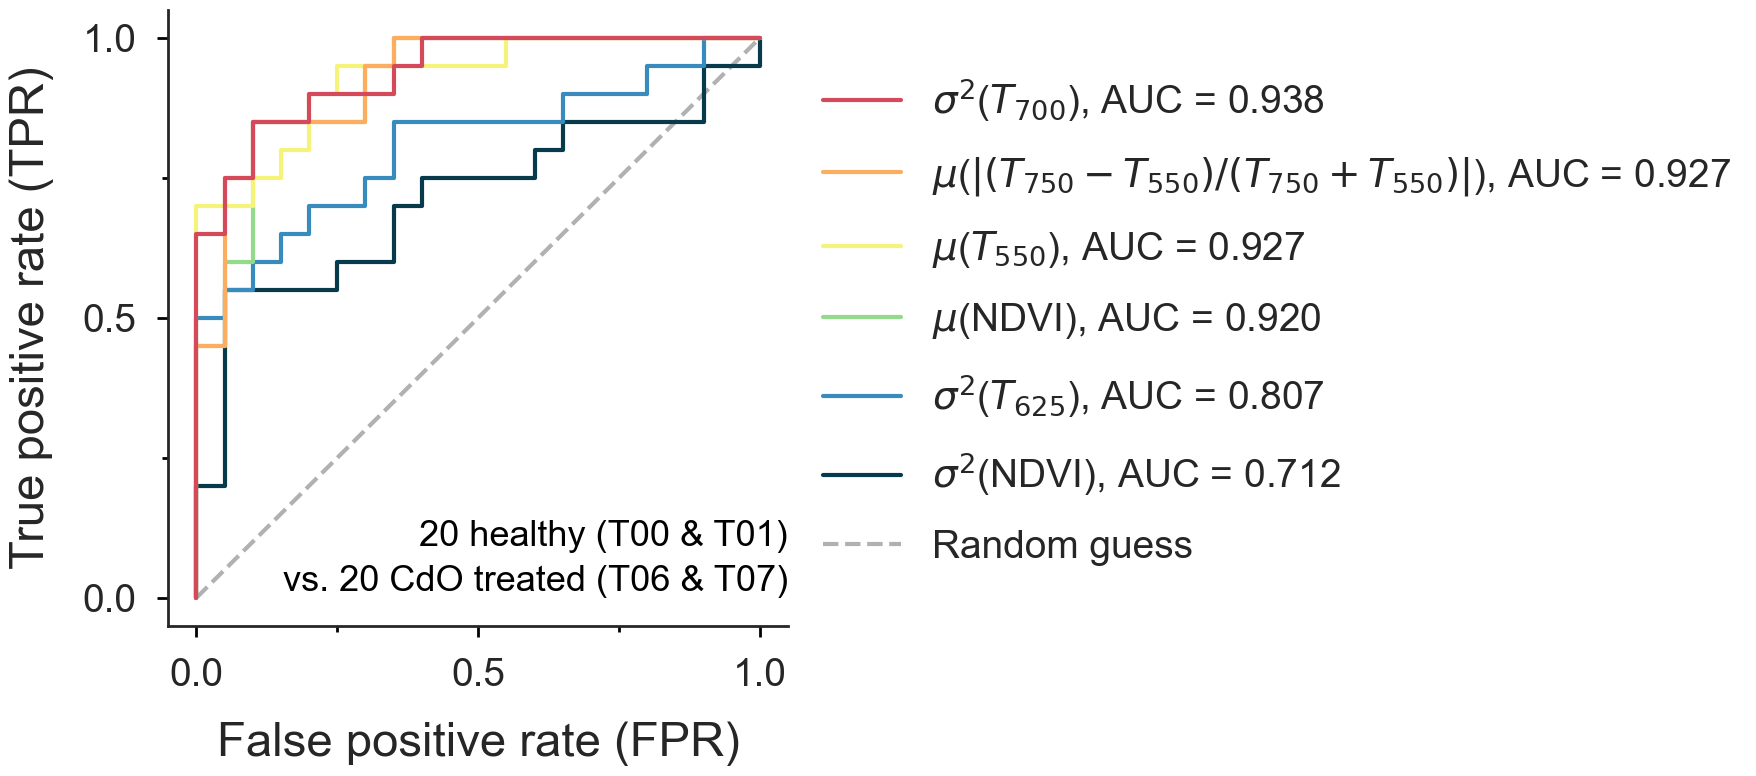

In [21]:
#########################
# Select the features (and their corresponding plot colors) to include in the figure.
feature_list = ['Var_$T_{700}$','Mean_$|(T_{750}-T_{550})/(T_{750}+T_{550})|$','Mean_$T_{550}$',
                'Mean_NDVI','Var_$T_{625}$','Var_NDVI',]
c_list = [colors.to_rgba("#d44a5a"),colors.to_rgba("#fdad60"),colors.to_rgba("#f5f37a"),
          colors.to_rgba("#92db8a"),colors.to_rgba("#398abd"),colors.to_rgba("#073b4c")]
#########################


load_plt_setting()
fig, ax = plt.subplots(figsize=(8, 8))

i = 0
for index in feature_list:
    fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, np.array(indexes[index])[idx])
    roc_auc = sklearn.metrics.auc(fpr, tpr)
    if roc_auc < 0.5:
        fpr, tpr, thresholds = sklearn.metrics.roc_curve(labels, np.array(indexes[index])[idx], pos_label=0)
        roc_auc = sklearn.metrics.auc(fpr, tpr)
    if 'Mean' in index:
        label_name = '$\mu$' + '({})'.format(index[5:])
    elif 'Var' in index:
        label_name = '$\sigma^2$' + '({})'.format(index[4:])
    ax.plot(fpr, tpr, linewidth=3, c=c_list[i], clip_on=False, 
            label=label_name+', AUC = {:.3f}'.format(roc_auc), zorder=10-i)
    i += 1
ax.plot([0,1], [0,1], linewidth=3, c=colors.to_rgba("#b1b1b1"), linestyle='--', clip_on=False, label='Random guess')

ax.axes.set_xlim([-0.05,1.05])
ax.axes.set_ylim([-0.05,1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
ax.tick_params(axis='both',direction='out',length=8,width=2,pad=15,color='black',labelsize=28)
ax.tick_params(axis='both',which='minor',direction='out',length=4,width=2,pad=15,color='black',labelsize=28)
ax.set_xlabel('False positive rate (FPR)', labelpad=20, fontsize=34)
ax.set_ylabel('True positive rate (TPR)', labelpad=20, fontsize=34)

ax.legend(bbox_to_anchor=(1, 0.95), fontsize=28, labelspacing=0.8)

#########################
# Add some labels.
ax.text(1.05, 0.08, '20 healthy (T00 & T01)', ha='right', va='bottom', c='k', size=26)
ax.text(1.05, 0, 'vs. 20 CdO treated (T06 & T07)', ha='right', va='bottom', c='k', size=26)
#########################

plt.savefig(os.path.join(root_path,'results',dataset_name,'ROC-AUC.png'), 
            format='png', dpi=300, transparent=True, bbox_inches='tight')

C:\Users\axvcb\AppData\Local\Temp\ipykernel_85468\1638741627.py:57: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  mpl.style.use('seaborn-white')


Text(1.5, 3, 'N = 20')

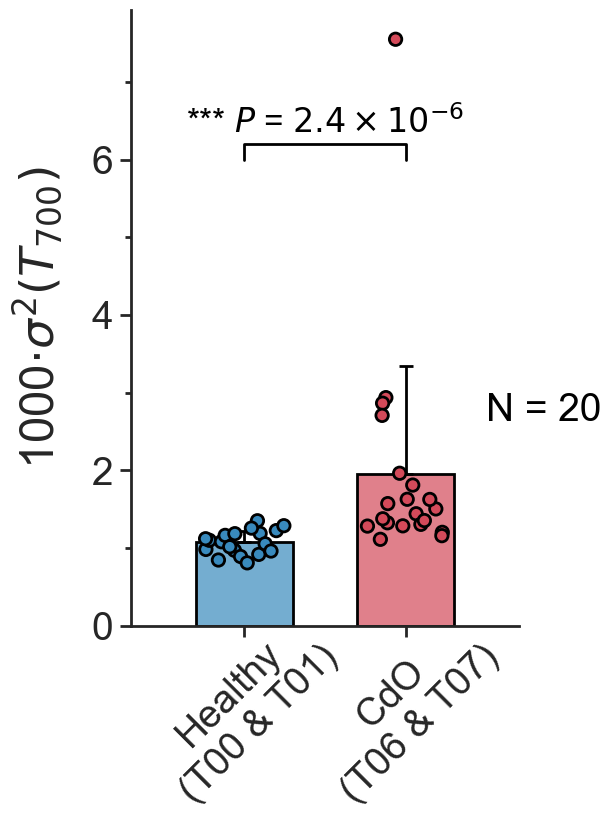

In [27]:
#########################
# Plot the selected feature to visualize its distribution.
# This is a simple, customizable visualization that you can modify as needed.
#########################

c_list = [colors.to_rgba("#398abd"),colors.to_rgba("#d44a5a")]

load_plt_setting()
fig, ax = plt.subplots(figsize=(5,8))

for i, idx_group in enumerate([idx[:20],idx[20:]]):
    y = np.array(np.array(indexes['Var_$T_{700}$'])[idx_group])*1000
    x_variation = 0.25
    x = np.random.uniform(i-x_variation, i+x_variation, size=y.shape[0])
    ax.scatter(x, y, c=[c_list[i]]*y.shape[0], alpha=1, s=80, edgecolor="black", linewidth=2, clip_on=False)

    y_mean, y_error = mean_confidence_interval(y)
    ax.bar(i, y_mean, color=[c_list[i][:-1]+(0.7,)], width=0.6, zorder=-1, linewidth=2, edgecolor="black")
    ax.errorbar(i, y_mean, yerr=[[0],[np.std(y)]], elinewidth=2, ecolor='black', capsize=5, capthick=2, zorder=-1)

ax.tick_params(axis='both', direction='out', length=8, width=2, pad=5, labelsize=28)
ax.tick_params(axis='both', which='minor', direction='out', length=4, width=2, pad=10)
ax.tick_params(axis='x', direction='out', length=8, width=2, pad=5, labelsize=28)
ax.tick_params(axis='x', pad=-20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
# ax.set_ylim([0,4])
ax.set_xlim([-0.7,2-0.3])

plt.xticks(np.linspace(0,2-1,2), ['Healthy\n(T00 & T01)','CdO\n(T06 & T07)'], size=28, rotation=45)
ax.set_ylabel('1000$\cdot\sigma^2$'+'$(T_{{{}}})$'.format(700), labelpad=20, fontsize=34)

U, p = scipy.stats.mannwhitneyu(np.array(indexes['Var_$T_{700}$'])[idx[:20]], 
                                np.array(indexes['Var_$T_{700}$'])[idx[20:]], alternative='two-sided')
# print(p)

def as_si(x, ndp):
    s = '{x:0.{ndp:d}e}'.format(x=x, ndp=ndp)
    m, e = s.split('e')
    return r'{m:s}\times 10^{{{e:d}}}'.format(m=m, e=int(e))

ax.plot([0,0,1,1], [3+3, 3.2+3, 3.2+3, 3+3], c='black', linewidth=2, clip_on=False)
ax.text(0.5, 3.25+3, '*** ${P}$ = ' + '${}$'.format(as_si(p,1)), ha='center', va='bottom', c='k', size=24)
ax.text(1.5, 3, 'N = 20', ha='left', va='top', c='k', size=28)